# EDA for all data

### imports and config

In [2]:
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
from training.dataset.load import load_all_data

## 1. Structure

In [5]:
df = load_all_data()
print(df.shape)

(14412, 2)


In [6]:
print(df.isnull().sum()) # Missing values

text     0
label    0
dtype: int64


In [7]:
print(f"\nDtypes:\n{df.dtypes}")


Dtypes:
text       str
label    int64
dtype: object


## 2. Class balance

In [8]:
print("Label distribution:")
print(df["label"].value_counts())
print(f"\nIn percent:")
print(df["label"].value_counts(normalize=True))

Label distribution:
label
0    9586
1    4826
Name: count, dtype: int64

In percent:
label
0    0.66514
1    0.33486
Name: proportion, dtype: float64


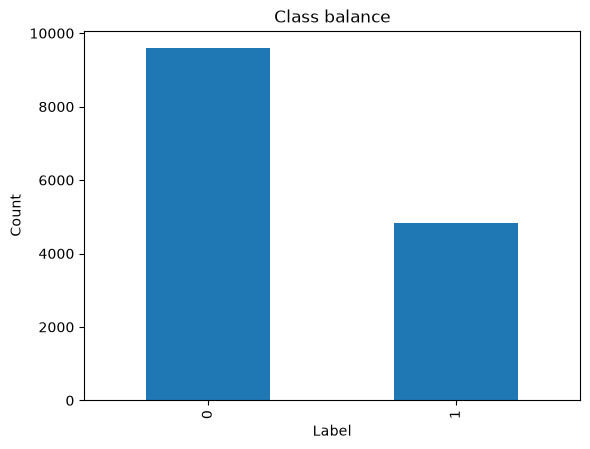

In [9]:
df["label"].value_counts().plot(kind="bar", title="Class balance")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## 3. Text length

In [10]:
df["length"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("Character length:")
print(df["length"].describe())

print("\nWord count:")
print(df["word_count"].describe())

Character length:
count    14412.000000
mean       177.458646
std        271.614441
min         21.000000
25%         58.000000
50%        102.000000
75%        198.000000
max       7405.000000
Name: length, dtype: float64

Word count:
count    14412.000000
mean        27.946017
std         41.432218
min          1.000000
25%          9.000000
50%         16.000000
75%         32.000000
max       1078.000000
Name: word_count, dtype: float64


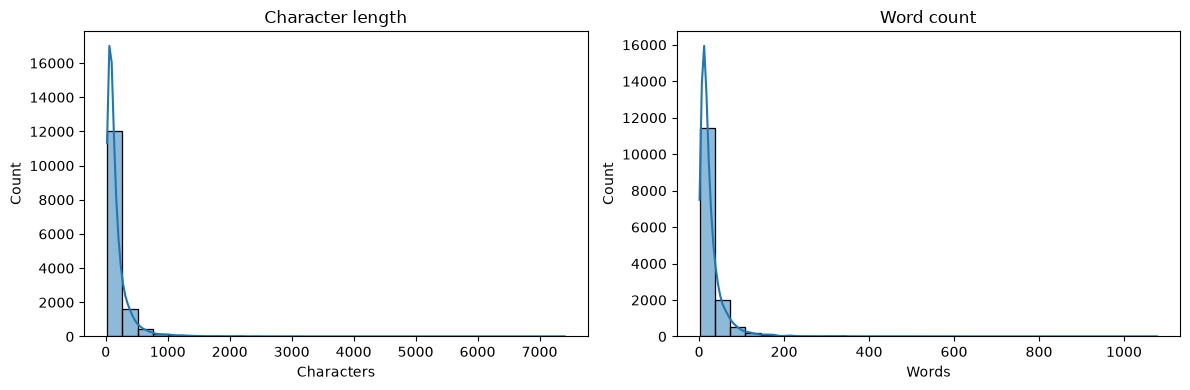

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["length"], bins=30, kde=True, ax=axes[0], edgecolor="black")
axes[0].set_title("Character length")
axes[0].set_xlabel("Characters")

sns.histplot(df["word_count"], bins=30, kde=True, ax=axes[1], edgecolor="black")
axes[1].set_title("Word count")
axes[1].set_xlabel("Words")

plt.tight_layout()
plt.show()

In [12]:
print(df.groupby("label")["length"].describe()) # Grouped by classes

        count        mean         std   min   25%    50%    75%     max
label                                                                  
0      9586.0  195.149176  274.764424  21.0  67.0  119.0  224.0  7405.0
1      4826.0  142.319519  261.751675  21.0  46.0   77.0  141.0  5219.0


In [13]:
print(df.groupby("label")["word_count"].describe()) # Grouped by classes

        count       mean        std  min   25%   50%   75%     max
label                                                             
0      9586.0  30.713436  40.811415  2.0  11.0  19.0  36.0  1012.0
1      4826.0  22.449026  42.106674  1.0   7.0  12.0  23.0  1078.0


In [14]:
df['length'].quantile(0.999)

np.float64(3498.407999999996)

In [15]:
df[df['length'] > 3000]

,text,label,length,word_count
41,Ну давай разберём всё тобой написанное. Бляядь...,1,3456,550
214,"Раз уж вакханалия продолжается, давайте в этом...",0,4372,678
377,"в писанине указано, что Ссаколов реально не уп...",1,3390,495
471,"Не знаю, что он там вам показал, если вы не сп...",0,3083,467
486,"та ну, хуйня это все про джентельменство . мен...",0,3655,605
553,На одном из симпозиумов встретились четыре лин...,0,3753,493
659,"Знаете, моя подруга живёт с мужчиной, который ...",1,3929,676
1628,"именно так. смотрю на тебя, стаса, вестника ду...",1,4214,666
1660,"дерейлы тредов за счёт постоянных провокаций, ...",1,3805,598
1819,Чаще всего агрессия и агрессивность проявляетс...,1,3021,416


In [16]:
df['word_count'].quantile(0.999)

np.float64(500.8899999999994)

In [17]:
df[df['word_count'] > 500]

,text,label,length,word_count
41,Ну давай разберём всё тобой написанное. Бляядь...,1,3456,550
214,"Раз уж вакханалия продолжается, давайте в этом...",0,4372,678
486,"та ну, хуйня это все про джентельменство . мен...",0,3655,605
659,"Знаете, моя подруга живёт с мужчиной, который ...",1,3929,676
1628,"именно так. смотрю на тебя, стаса, вестника ду...",1,4214,666
1660,"дерейлы тредов за счёт постоянных провокаций, ...",1,3805,598
1953,"В Киеве на вокзале Мен було рок в 19, коли мен...",1,4921,1078
2064,С начала года свыше 40 тысяч россиян объявили ...,0,7405,1012
3016,"Блеаадь, как же обидно когда создаешь тред, па...",1,5219,787
5795,С 19 апреля в Николаеве будет действовать запр...,0,5175,741


## 4. Words top

In [18]:
import re
from collections import Counter

def tokenize(text):
    return re.findall(r"[а-яёa-z]+", text.lower())

toxic_words = Counter(
    w for t in df[df["label"] == 1]["text"]
    for w in tokenize(t)
)
print("=== Top 30 toxic words ===")
for w, c in toxic_words.most_common(30):
    print(f"{w}: {c}")

neutral_words = Counter(
    w for t in df[df["label"] == 0]["text"]
    for w in tokenize(t)
)
print("\n=== Top 30 neutral words ===")
for w, c in neutral_words.most_common(30):
    print(f"{w}: {c}")

=== Top 30 toxic words ===
и: 3363
в: 2783
не: 2665
на: 1721
что: 1610
а: 1363
с: 1123
ты: 1076
это: 1057
то: 918
как: 916
я: 854
у: 795
по: 641
за: 614
так: 539
он: 535
же: 520
но: 448
все: 444
из: 404
бы: 389
к: 370
ну: 370
от: 363
просто: 361
да: 360
если: 355
его: 328
или: 326

=== Top 30 neutral words ===
и: 9323
в: 9203
не: 7636
на: 5282
что: 4376
а: 3655
с: 3182
это: 2913
то: 2847
как: 2345
я: 2319
но: 2255
по: 2225
у: 2116
так: 1766
за: 1717
если: 1556
все: 1418
из: 1221
к: 1219
для: 1198
же: 1146
от: 1119
есть: 1067
только: 1065
или: 1000
там: 967
вот: 900
можно: 891
было: 880


## 5. Duplicates

In [19]:
dups = df[df.duplicated(subset=["text"], keep=False)]
print(f"Duplicates: {len(dups)} ({100*len(dups)/len(df):.2f}%)")

print("\nSample duplicates:")
for t in dups["text"].head(20):
    print(f"- {t}")

Duplicates: 0 (0.00%)

Sample duplicates:
